## Cell 1 — Imports

In [ ]:
!pip install -q torch scikit-learn pandas numpy matplotlib requests

import warnings, random, math, time, sys, os, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Determinism flags — reduces GPU non-determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

import gzip, json as js, urllib.request
DATASET_NAME = 'Amazon Beauty'
DATASET_TAG  = 'beauty'

Device : cuda
PyTorch: 2.10.0+cu128


## Cell 2 — Download Amazon Beauty 5-core

In [ ]:
FILE = 'beauty.json.gz'
URL  = ('https://snap.stanford.edu/data/amazon/productGraph/'
        'categoryFiles/reviews_Beauty_5.json.gz')

if not os.path.exists(FILE):
    print('Downloading Amazon Beauty 5-core (~32 MB)...')
    urllib.request.urlretrieve(URL, FILE)
    print('Done.')
else:
    print(f'{FILE} already present, skipping download.')

rows = []
with gzip.open(FILE, 'rb') as f:
    for line in f:
        try:
            d = js.loads(line)
            rows.append({'user_id'   : d['reviewerID'],
                         'item_id'   : d['asin'],
                         'rating'    : float(d['overall']),
                         'timestamp' : int(d.get('unixReviewTime', 0))})
        except: continue

df_raw = pd.DataFrame(rows)
df_raw.sort_values(['user_id','timestamp'], inplace=True)
df_raw.drop_duplicates(subset=['user_id','item_id'], keep='last', inplace=True)
df_raw.reset_index(drop=True, inplace=True)

user_enc  = LabelEncoder(); item_enc = LabelEncoder()
df_raw['user_idx'] = user_enc.fit_transform(df_raw['user_id'])
df_raw['item_idx'] = item_enc.fit_transform(df_raw['item_id'])

N_USERS  = df_raw['user_idx'].nunique()
N_MOVIES = df_raw['item_idx'].nunique()
N_GENDERS = 2; N_OCCS = 2  # no demographics — use dummies

print(f'Users: {N_USERS:,} | Items: {N_MOVIES:,} | Reviews: {len(df_raw):,}')
print(f'Avg/user: {len(df_raw)/N_USERS:.1f} | Sparsity: {1-len(df_raw)/(N_USERS*N_MOVIES):.4%}')

Done.
Users: 22,363 | Items: 12,101 | Reviews: 198,502
Avg/user: 8.9 | Sparsity: 99.9266%


## Cell 3 — Split & Config

In [ ]:
SHORT_LEN   = 5     # Beauty users have shorter histories (avg ~8)
LONG_LEN    = 20
MIN_HIST    = 5
N_NEG_TRAIN = 5
BATCH        = 256
D_MODEL      = 64   # smaller — fewer items → less capacity needed
LR           = 1e-3
LAMBDA_BPR   = 0.5
EVAL_EVERY   = 5

print(f'Sequence windows: short={SHORT_LEN}, long={LONG_LEN}')
print(f'Embedding dim   : {D_MODEL}')
print()
print('Expected training time:')
print('  Colab T4 GPU : ~10-15 min (50 epochs)')
print('  CPU only     : ~2-3 hrs')

user_history = {}; user_meta = {}
for uid, grp in df_raw.groupby('user_idx', sort=True):
    user_history[uid] = grp.sort_values('timestamp')['item_idx'].tolist()
    user_meta[uid]    = (0.5, 0, 0)  # dummy demographics

user_all_items = {uid: set(h) for uid, h in user_history.items()}

train_data, valid_data, test_data = [], [], []
for uid, hist in user_history.items():
    if len(hist) < MIN_HIST: continue
    train_hist = hist[:-2]
    for i in range(1, len(train_hist)):
        ctx = train_hist[max(0, i-LONG_LEN): i]
        train_data.append((uid, ctx, train_hist[i]))
    ctx_vt = train_hist[-LONG_LEN:]
    valid_data.append((uid, ctx_vt, hist[-2]))
    test_data.append( (uid, ctx_vt, hist[-1]))

print(f'\nTrain: {len(train_data):,} | Valid: {len(valid_data):,} | Test: {len(test_data):,}')

Sequence windows: short=5, long=20
Embedding dim   : 64

Expected training time:
  Colab T4 GPU : ~10-15 min (50 epochs)
  CPU only     : ~2-3 hrs

Train: 131,413 | Valid: 22,363 | Test: 22,363


## Cell 4 — Dataset & DataLoader

In [ ]:
def pad_or_trim(seq, length):
    """Pad with 0 or trim to exact length."""
    if len(seq) >= length:
        return seq[-length:]
    return [0] * (length - len(seq)) + seq


class DSASRv2Dataset(Dataset):
    """
    Generic dataset for all corpora (MovieLens, Beauty).
    No genre_lookup required — genre features were removed from DSASR-v2
    to keep the architecture corpus-agnostic.
    Each sample yields: padded long/short sequences + pos item + N_NEG_TRAIN negatives.
    """
    def __init__(self, data, user_all_items, n_movies,
                 short_len, long_len, n_neg, user_meta):
        self.data       = data
        self.user_items = user_all_items
        self.n_movies   = n_movies
        self.short_len  = short_len
        self.long_len   = long_len
        self.n_neg      = n_neg
        self.user_meta  = user_meta

    def __len__(self):
        return len(self.data)

    def _sample_negatives(self, uid, k):
        negs = []
        seen = self.user_items.get(uid, set())
        while len(negs) < k:
            neg = random.randint(0, self.n_movies - 1)
            if neg not in seen:
                negs.append(neg)
        return negs

    def __getitem__(self, idx):
        uid, context, pos_item = self.data[idx]
        negs      = self._sample_negatives(uid, self.n_neg)
        long_seq  = pad_or_trim(context, self.long_len)
        short_seq = long_seq[-self.short_len:]
        age, gender, occ = self.user_meta[uid]
        return {
            'user_idx'  : torch.tensor(uid,       dtype=torch.long),
            'age_norm'  : torch.tensor([age],     dtype=torch.float32),
            'gender_enc': torch.tensor(gender,    dtype=torch.long),
            'occ_enc'   : torch.tensor(occ,       dtype=torch.long),
            'long_seq'  : torch.tensor(long_seq,  dtype=torch.long),
            'short_seq' : torch.tensor(short_seq, dtype=torch.long),
            'pos_item'  : torch.tensor(pos_item,  dtype=torch.long),
            'neg_items' : torch.tensor(negs,      dtype=torch.long),
        }


train_set    = DSASRv2Dataset(train_data, user_all_items, N_MOVIES,
                              SHORT_LEN, LONG_LEN, N_NEG_TRAIN, user_meta)
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=0, drop_last=False)
print(f'Train loader ready: {len(train_loader)} batches')

Train loader ready: 514 batches


## Cell 5 — Model

In [ ]:
class CausalTransformerBlock(nn.Module):
    """
    Transformer block with CAUSAL (left-to-right) masking.
    Position i can only attend to positions 0..i — no future leakage.
    Same as SASRec.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.ff1   = nn.Linear(d_model, d_ff)
        self.ff2   = nn.Linear(d_ff, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, causal=True):
        B, T, _ = x.shape
        if causal:
            # Upper-triangular mask: positions can only see past
            mask = torch.triu(
                torch.ones(T, T, device=x.device), diagonal=1
            ).bool()
        else:
            mask = None
        attn_out, _ = self.attn(x, x, x, attn_mask=mask)
        x = self.norm1(x + self.drop(attn_out))
        ff = self.ff2(self.drop(F.gelu(self.ff1(x))))
        x  = self.norm2(x + self.drop(ff))
        return x


class ConsistencyGate(nn.Module):
    """
    Novel contribution: learns a per-user, per-prediction blend weight g
    between the short-term and long-term sequence representations.
    drift = 1 - cosine_similarity(short, long)
    g = sigmoid(MLP([short || long || drift || user_ctx]))
    blended = g * short + (1-g) * long
    """
    def __init__(self, d_model, ctx_dim, hidden=64):
        super().__init__()
        gate_in = d_model * 2 + 1 + ctx_dim
        self.net  = nn.Sequential(
            nn.Linear(gate_in, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )

    def forward(self, short, long_, user_ctx):
        drift   = (1.0 - F.cosine_similarity(short, long_, dim=-1, eps=1e-8)).unsqueeze(-1)
        gate_in = torch.cat([short, long_, drift, user_ctx], dim=-1)
        g       = self.net(gate_in)                   # (B, 1)
        blended = g * short + (1 - g) * long_
        return blended, g


class DSASRv2(nn.Module):
    """
    DSASR-v2: Dual-Stream Adaptive Sequential Recommendation

    Architecture:
      1. Movie embedding (shared table, d=128)
      2. Learnable positional encoding per stream
      3. Short-term transformer (causal, 2 blocks, uses last SHORT_LEN items)
      4. Long-term transformer (causal, 2 blocks, uses last LONG_LEN items)
      5. Consistency Gate: learns drift-aware blend of short and long repr
      6. User context (user_emb + gender + occ + age) injected into gate
      7. Scoring: dot product of blended repr with candidate item embedding
         (same mechanism as SASRec — directly optimises ranking)

    Training loss:
      L = BCE(pos_score, 1) + BCE(neg_score, 0)  [for each negative]
      + lambda * BPR(pos_score - neg_score mean)
    """
    def __init__(self, n_users, n_movies, n_genders, n_occs,
                 d_model=128, n_heads=4, d_ff=256, n_layers=2,
                 short_len=10, long_len=50, dropout=0.2):
        super().__init__()
        self.d_model   = d_model
        self.short_len = short_len
        self.long_len  = long_len

        # ── Embedding tables ───────────────────────────────────────────────
        # n_movies+1 because 0 is padding index
        self.movie_emb  = nn.Embedding(n_movies + 1, d_model, padding_idx=0)
        self.user_emb   = nn.Embedding(n_users  + 1, d_model)
        self.gender_emb = nn.Embedding(n_genders + 1, 8)
        self.occ_emb    = nn.Embedding(n_occs   + 1, 16)

        # Initialise movie embeddings with small normal (helps convergence)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.normal_(self.user_emb.weight,  std=0.01)

        # ── Positional encodings (separate per stream) ─────────────────────
        self.pos_short = nn.Embedding(short_len + 1, d_model)
        self.pos_long  = nn.Embedding(long_len  + 1, d_model)
        nn.init.normal_(self.pos_short.weight, std=0.01)
        nn.init.normal_(self.pos_long.weight,  std=0.01)

        # ── Transformer encoders ───────────────────────────────────────────
        # Short: CAUSAL (matches SASRec design, prevents future leakage)
        self.enc_short = nn.ModuleList(
            [CausalTransformerBlock(d_model, n_heads, d_ff, dropout)
             for _ in range(n_layers)])
        # Long: bidirectional (sees full history context)
        self.enc_long  = nn.ModuleList(
            [CausalTransformerBlock(d_model, n_heads, d_ff, dropout)
             for _ in range(n_layers)])

        # ── User context ───────────────────────────────────────────────────
        # user_emb(128) + gender(8) + occ(16) + age(1) = 153
        ctx_dim = d_model + 8 + 16 + 1
        self.ctx_proj = nn.Linear(ctx_dim, d_model)   # project to d_model for gate

        # ── Consistency Gate ───────────────────────────────────────────────
        self.gate = ConsistencyGate(d_model, d_model, hidden=d_model)

        # ── Layer norms & dropout ─────────────────────────────────────────
        self.emb_dropout = nn.Dropout(dropout)
        self.out_norm    = nn.LayerNorm(d_model)

    def encode_sequence(self, seq_ids, pos_emb, encoder_blocks, causal=True):
        """
        Encode a padded sequence of item ids.
        seq_ids: (B, T)  — 0 = padding
        Returns: (B, T, d_model)  — last position is the summary used
        """
        B, T    = seq_ids.shape
        m_emb   = self.movie_emb(seq_ids)              # (B, T, d)
        pos     = torch.arange(T, device=seq_ids.device).unsqueeze(0)  # (1, T)
        p_emb   = pos_emb(pos)                         # (1, T, d)
        x       = self.emb_dropout(m_emb + p_emb)      # (B, T, d)
        for block in encoder_blocks:
            x = block(x, causal=causal)
        return x

    def get_sequence_repr(self, batch):
        """
        Returns blended repr (B, d) and gate value g (B, 1).
        """
        dev      = next(self.parameters()).device
        long_seq = batch['long_seq'].to(dev)    # (B, LONG_LEN)
        short_seq= batch['short_seq'].to(dev)   # (B, SHORT_LEN)
        u_idx    = batch['user_idx'].to(dev)
        g_idx    = batch['gender_enc'].to(dev)
        o_idx    = batch['occ_enc'].to(dev)
        age      = batch['age_norm'].to(dev)

        # Encode both streams; take last non-padding position
        long_enc  = self.encode_sequence(long_seq,  self.pos_long,  self.enc_long,  causal=True)
        short_enc = self.encode_sequence(short_seq, self.pos_short, self.enc_short, causal=True)

        # Take the LAST position as the sequence representation
        # (SASRec style: position -1 predicts the next item)
        long_repr  = long_enc[:, -1, :]    # (B, d)
        short_repr = short_enc[:, -1, :]   # (B, d)

        # User context
        u_emb    = self.user_emb(u_idx)     # (B, d)
        g_emb    = self.gender_emb(g_idx)   # (B, 8)
        o_emb    = self.occ_emb(o_idx)      # (B, 16)
        user_ctx = torch.cat([u_emb, g_emb, o_emb, age], dim=-1)  # (B, 153)
        user_ctx_proj = self.ctx_proj(user_ctx)  # (B, d)

        # Consistency Gate
        blended, gate_val = self.gate(short_repr, long_repr, user_ctx_proj)
        blended = self.out_norm(blended)    # (B, d)

        return blended, gate_val

    def score(self, seq_repr, item_ids):
        """
        Score items via dot product (SASRec mechanism).
        seq_repr: (B, d)
        item_ids: (B,) or (B, K)
        Returns: (B,) or (B, K)
        """
        if item_ids.dim() == 1:
            item_emb = self.movie_emb(item_ids)          # (B, d)
            return (seq_repr * item_emb).sum(dim=-1)      # (B,)
        else:
            item_emb = self.movie_emb(item_ids)          # (B, K, d)
            return torch.bmm(item_emb, seq_repr.unsqueeze(-1)).squeeze(-1)  # (B, K)

    def forward(self, batch):
        blended, gate_val = self.get_sequence_repr(batch)
        dev = next(self.parameters()).device
        pos_score = self.score(blended, batch['pos_item'].to(dev))
        neg_score = self.score(blended, batch['neg_items'].to(dev))  # (B, K)
        return pos_score, neg_score, gate_val


# Instantiate
D_MODEL = 128
N_LAYERS = 2

model = DSASRv2(
    n_users  = N_USERS,
    n_movies = N_MOVIES,
    n_genders= N_GENDERS,
    n_occs   = N_OCCS,
    d_model  = D_MODEL,
    n_heads  = 4,
    d_ff     = D_MODEL * 4,
    n_layers = N_LAYERS,
    short_len= SHORT_LEN,
    long_len = LONG_LEN,
    dropout  = 0.2,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DSASR-v2 parameters: {total_params:,}')

DSASR-v2 parameters: 5,277,769


## Cell 6 — Loss

In [ ]:
def bce_loss(pos_score, neg_score):
    """
    Binary Cross-Entropy with negative sampling.
    pos_score: (B,)    — score for the ground-truth next item
    neg_score: (B, K)  — scores for K negative items

    Loss = -log(sigmoid(pos)) - mean_K(log(1 - sigmoid(neg)))
    This is exactly the SASRec training objective.
    """
    pos_loss = -F.logsigmoid(pos_score).mean()
    neg_loss = -F.logsigmoid(-neg_score).mean()
    return pos_loss + neg_loss


def bpr_loss(pos_score, neg_score):
    """
    Bayesian Personalised Ranking loss.
    Encourages pos_score > mean(neg_score).
    Complementary to BCE — adds pairwise ranking signal.
    """
    mean_neg = neg_score.mean(dim=-1)   # (B,)
    return -F.logsigmoid(pos_score - mean_neg).mean()


LAMBDA_BPR = 0.5   # weight on BPR term
LAMBDA_L2  = 1e-4  # L2 regularisation weight

## Cell 7 — Instantiate

In [ ]:
model = DSASRv2(
    n_users=N_USERS, n_movies=N_MOVIES, n_genders=N_GENDERS, n_occs=N_OCCS,
    d_model=D_MODEL, n_heads=4, d_ff=D_MODEL*4, n_layers=2,
    short_len=SHORT_LEN, long_len=LONG_LEN, dropout=0.2,
).to(DEVICE)
print(f'DSASR-v2 (Beauty) parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

DSASR-v2 (Beauty) parameters: 5,277,769


## Cell 8 — Train

In [ ]:
import time
import sys

# ── Batched validation — much faster than per-user loop ───────────────────
def quick_eval_batched(model, valid_data, user_all_items, n_movies,
                       n_sample=200, n_neg=99):
    """
    Evaluate HR@10 and NDCG@10 on a sample of validation users.
    Batches all candidates together for a single forward pass per user.
    ~10x faster than the per-user loop version.
    """
    model.eval()
    if len(valid_data) > n_sample:
        sample = random.sample(valid_data, n_sample)
    else:
        sample = valid_data

    hr10, ndcg10 = [], []

    with torch.no_grad():
        for uid, context, pos_item in sample:
            neg_pool = list(set(range(n_movies)) - user_all_items.get(uid, set()))
            negs     = random.sample(neg_pool, min(n_neg, len(neg_pool)))
            cands    = [pos_item] + negs
            B        = len(cands)

            long_seq  = pad_or_trim(context, LONG_LEN)
            short_seq = long_seq[-SHORT_LEN:]
            age, gender, occ = user_meta[uid]

            # Single forward pass for all B candidates at once
            batch = {
                'user_idx'  : torch.tensor([uid]*B,        dtype=torch.long,    device=DEVICE),
                'age_norm'  : torch.tensor([[age]]*B,       dtype=torch.float32, device=DEVICE),
                'gender_enc': torch.tensor([gender]*B,      dtype=torch.long,    device=DEVICE),
                'occ_enc'   : torch.tensor([occ]*B,         dtype=torch.long,    device=DEVICE),
                'long_seq'  : torch.tensor([long_seq]*B,    dtype=torch.long,    device=DEVICE),
                'short_seq' : torch.tensor([short_seq]*B,   dtype=torch.long,    device=DEVICE),
                'pos_item'  : torch.tensor(cands,           dtype=torch.long,    device=DEVICE),
                'neg_items' : torch.zeros(B, 1,             dtype=torch.long,    device=DEVICE),
            }

            blended, _ = model.get_sequence_repr(batch)
            scores = model.score(blended, batch['pos_item']).cpu().numpy()

            rank = 1 + int((scores[1:] > scores[0]).sum())
            hr10.append(1.0 if rank <= 10 else 0.0)
            ndcg10.append(1.0 / math.log2(rank + 1) if rank <= 10 else 0.0)

    model.train()
    return float(np.mean(hr10)), float(np.mean(ndcg10))


# ── Training configuration ────────────────────────────────────────────────
EPOCHS      = 50      # 50 is enough with cosine schedule + early stopping
LR          = 1e-3
PATIENCE    = 5       # stop if no improvement for 5 consecutive val checks
EVAL_EVERY  = 5       # validate every N epochs
LAMBDA_BPR  = 0.5
LAMBDA_L2   = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5)

train_losses  = []
val_hr10_hist = []
val_nd10_hist = []
best_hr10     = 0.0
best_nd10     = 0.0
best_state    = None
pat_counter   = 0

print(f"Training DSASR-v2 for up to {EPOCHS} epochs...")
print(f"Validating every {EVAL_EVERY} epochs on {min(200,len(valid_data))} users")
print(f"Device: {DEVICE}")
print("-" * 55)
sys.stdout.flush()

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for batch in train_loader:
        # Move batch to device
        for k in batch:
            batch[k] = batch[k].to(DEVICE)

        pos_score, neg_score, gate_val = model(batch)

        # BCE + BPR loss
        pos_loss = -F.logsigmoid(pos_score).mean()
        neg_loss = -F.logsigmoid(-neg_score).mean()
        bpr      = -F.logsigmoid(pos_score - neg_score.mean(dim=-1)).mean()
        l2       = (model.movie_emb.weight.norm(2) +
                    model.user_emb.weight.norm(2))
        loss = pos_loss + neg_loss + LAMBDA_BPR * bpr + LAMBDA_L2 * l2

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    train_losses.append(avg_loss)

    elapsed = (time.time() - t0) / 60
    print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Elapsed: {elapsed:.1f}m", end="")
    sys.stdout.flush()

    if epoch % EVAL_EVERY == 0:
        hr10, nd10 = quick_eval_batched(
            model, valid_data, user_all_items, N_MOVIES, n_sample=200)
        val_hr10_hist.append(hr10)
        val_nd10_hist.append(nd10)
        print(f" | Val HR@10: {hr10:.4f}  NDCG@10: {nd10:.4f}", end="")
        sys.stdout.flush()

        if hr10 > best_hr10:
            best_hr10   = hr10
            best_nd10   = nd10
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            pat_counter = 0
            print(" ✓ best", end="")
        else:
            pat_counter += 1
            if pat_counter >= PATIENCE:
                print(f"\nEarly stopping — no improvement for {PATIENCE} checks.")
                break
    print()
    sys.stdout.flush()

# Restore best model
if best_state:
    model.load_state_dict(best_state)

total_min = (time.time() - t0) / 60
print(f"\nDone in {total_min:.1f} min | Best Val HR@10={best_hr10:.4f} NDCG@10={best_nd10:.4f}")

Training DSASR-v2 for up to 50 epochs...
Validating every 5 epochs on 200 users
Device: cuda
-------------------------------------------------------
Epoch   1/50 | Loss: 1.3727 | Elapsed: 0.3m
Epoch   2/50 | Loss: 1.1277 | Elapsed: 0.5m
Epoch   3/50 | Loss: 0.9375 | Elapsed: 0.8m
Epoch   4/50 | Loss: 0.6860 | Elapsed: 1.1m
Epoch   5/50 | Loss: 0.4847 | Elapsed: 1.3m | Val HR@10: 0.5300  NDCG@10: 0.3525 ✓ best
Epoch   6/50 | Loss: 0.3627 | Elapsed: 1.6m
Epoch   7/50 | Loss: 0.2907 | Elapsed: 1.9m
Epoch   8/50 | Loss: 0.2452 | Elapsed: 2.1m
Epoch   9/50 | Loss: 0.2143 | Elapsed: 2.4m
Epoch  10/50 | Loss: 0.1917 | Elapsed: 2.6m | Val HR@10: 0.5100  NDCG@10: 0.3263
Epoch  11/50 | Loss: 0.1760 | Elapsed: 2.9m
Epoch  12/50 | Loss: 0.1644 | Elapsed: 3.2m
Epoch  13/50 | Loss: 0.1536 | Elapsed: 3.4m
Epoch  14/50 | Loss: 0.1441 | Elapsed: 3.7m
Epoch  15/50 | Loss: 0.1376 | Elapsed: 4.0m | Val HR@10: 0.4900  NDCG@10: 0.3317
Epoch  16/50 | Loss: 0.1293 | Elapsed: 4.2m
Epoch  17/50 | Loss: 0.1244 |

## Cell 9 — Evaluate

In [ ]:
model.eval()
NS         = (5, 10, 20)
N_NEG_EVAL = 99

hr_scores   = {n: [] for n in NS}
ndcg_scores = {n: [] for n in NS}
mrr_scores  = {n: [] for n in NS}

with torch.no_grad():
    for uid, context, pos_item in test_data:
        neg_pool  = list(set(range(N_MOVIES)) - user_all_items.get(uid, set()))
        negs      = random.sample(neg_pool, min(N_NEG_EVAL, len(neg_pool)))
        cands     = [pos_item] + negs
        B         = len(cands)
        long_seq  = pad_or_trim(context, LONG_LEN)
        short_seq = long_seq[-SHORT_LEN:]
        age, gender, occ = user_meta[uid]
        batch = {
            'user_idx'  : torch.tensor([uid]*B,        dtype=torch.long,    device=DEVICE),
            'age_norm'  : torch.tensor([[age]]*B,       dtype=torch.float32, device=DEVICE),
            'gender_enc': torch.tensor([gender]*B,      dtype=torch.long,    device=DEVICE),
            'occ_enc'   : torch.tensor([occ]*B,         dtype=torch.long,    device=DEVICE),
            'long_seq'  : torch.tensor([long_seq]*B,    dtype=torch.long,    device=DEVICE),
            'short_seq' : torch.tensor([short_seq]*B,   dtype=torch.long,    device=DEVICE),
            'pos_item'  : torch.tensor(cands,           dtype=torch.long,    device=DEVICE),
            'neg_items' : torch.zeros(B, N_NEG_TRAIN,   dtype=torch.long,    device=DEVICE),
        }
        blended, _ = model.get_sequence_repr(batch)
        scores     = model.score(blended, batch['pos_item']).cpu().numpy()
        rank       = 1 + int((scores[1:] > scores[0]).sum())
        for n in NS:
            hr_scores[n].append(  1.0 if rank<=n else 0.0)
            ndcg_scores[n].append(1.0/math.log2(rank+1) if rank<=n else 0.0)
            mrr_scores[n].append( 1.0/rank if rank<=n else 0.0)

hr_mean   = {n: np.mean(hr_scores[n])   for n in NS}
ndcg_mean = {n: np.mean(ndcg_scores[n]) for n in NS}
mrr_mean  = {n: np.mean(mrr_scores[n])  for n in NS}

print('='*65)
print(f'       DSASR-v2 — {DATASET_NAME}')
print( '       Protocol: leave-one-out + 99 negative sampling')
print('='*65)
for n in NS:
    print(f'  HR@{n:<2}: {hr_mean[n]:.4f}   NDCG@{n:<2}: {ndcg_mean[n]:.4f}   MRR@{n:<2}: {mrr_mean[n]:.4f}')
print('='*65)

       DSASR-v2 — Amazon Beauty
       Protocol: leave-one-out + 99 negative sampling
  HR@5 : 0.3277   NDCG@5 : 0.2339   MRR@5 : 0.2030
  HR@10: 0.4353   NDCG@10: 0.2686   MRR@10: 0.2172
  HR@20: 0.5617   NDCG@20: 0.3005   MRR@20: 0.2259


## Cell 10 — Ablation

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ABLATION STUDY
# Tests 4 configurations to isolate each component's contribution:
#   Config 1 — Single-stream (long only)  + BCE only        (no gate, no BPR)
#   Config 2 — Single-stream (long only)  + BCE + BPR       (no gate)
#   Config 3 — Dual-stream, mean fusion   + BCE + BPR       (no gate)
#   Config 4 — Full DSASR-v2 (dual-stream + Consistency Gate + BCE + BPR)
# Config 4 results come from the already-trained model above.
# ════════════════════════════════════════════════════════════════════════════

ABLATION_EPOCHS = 30   # fewer epochs — enough to estimate contribution

def run_ablation(model_cls, use_bpr, label):
    """Train an ablation variant for ABLATION_EPOCHS and evaluate."""
    print(f"\n── {label} ──")
    m = model_cls(
        n_users=N_USERS, n_movies=N_MOVIES, n_genders=N_GENDERS, n_occs=N_OCCS,
        d_model=D_MODEL, n_heads=4, d_ff=D_MODEL*4, n_layers=2,
        short_len=SHORT_LEN, long_len=LONG_LEN, dropout=0.2,
    ).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=0.0)

    m.train()
    for epoch in range(1, ABLATION_EPOCHS+1):
        for batch in train_loader:
            for k in batch: batch[k] = batch[k].to(DEVICE)
            ps, ns, _ = m(batch)
            loss = bce_loss(ps, ns)
            if use_bpr:
                loss = loss + LAMBDA_BPR * (-F.logsigmoid(ps - ns.mean(-1)).mean())
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 5.0)
            opt.step()
        if epoch % 10 == 0:
            print(f"  Epoch {epoch}/{ABLATION_EPOCHS}")

    # Evaluate
    m.eval()
    hr10, nd10, mr10 = [], [], []
    N_ABL = 99
    with torch.no_grad():
        for uid, context, pos_item in test_data:
            neg_pool  = list(set(range(N_MOVIES)) - user_all_items.get(uid, set()))
            negs      = random.sample(neg_pool, min(N_ABL, len(neg_pool)))
            cands     = [pos_item] + negs
            B         = len(cands)
            long_seq  = pad_or_trim(context, LONG_LEN)
            short_seq = long_seq[-SHORT_LEN:]
            age, gender, occ = user_meta[uid]
            batch = {
                'user_idx'  : torch.tensor([uid]*B,        dtype=torch.long,    device=DEVICE),
                'age_norm'  : torch.tensor([[age]]*B,       dtype=torch.float32, device=DEVICE),
                'gender_enc': torch.tensor([gender]*B,      dtype=torch.long,    device=DEVICE),
                'occ_enc'   : torch.tensor([occ]*B,         dtype=torch.long,    device=DEVICE),
                'long_seq'  : torch.tensor([long_seq]*B,    dtype=torch.long,    device=DEVICE),
                'short_seq' : torch.tensor([short_seq]*B,   dtype=torch.long,    device=DEVICE),
                'pos_item'  : torch.tensor(cands,           dtype=torch.long,    device=DEVICE),
                'neg_items' : torch.zeros(B, N_NEG_TRAIN,   dtype=torch.long,    device=DEVICE),
            }
            blended, _ = m.get_sequence_repr(batch)
            scores = m.score(blended, batch['pos_item']).cpu().numpy()
            rank   = 1 + int((scores[1:] > scores[0]).sum())
            hr10.append(  1.0 if rank<=10 else 0.0)
            nd10.append(  1.0/math.log2(rank+1) if rank<=10 else 0.0)
            mr10.append(  1.0/rank if rank<=10 else 0.0)

    return np.mean(hr10), np.mean(nd10), np.mean(mr10)


# ── Config 1: Single-stream (long only), no gate, BCE only ─────────────────
class DSASRv2_C1(DSASRv2):
    def get_sequence_repr(self, batch):
        dev = next(self.parameters()).device
        long_seq = batch['long_seq'].to(dev)
        long_enc = self.encode_sequence(long_seq, self.pos_long, self.enc_long, causal=True)
        repr_    = self.out_norm(long_enc[:, -1, :])
        return repr_, torch.zeros(repr_.shape[0], 1, device=dev)

# ── Config 2: Single-stream (long only), no gate, BCE + BPR ────────────────
class DSASRv2_C2(DSASRv2_C1):
    pass   # same architecture, training adds BPR

# ── Config 3: Dual-stream, mean fusion (no gate), BCE + BPR ────────────────
class DSASRv2_C3(DSASRv2):
    def get_sequence_repr(self, batch):
        dev = next(self.parameters()).device
        long_seq  = batch['long_seq'].to(dev)
        short_seq = batch['short_seq'].to(dev)
        l_enc = self.encode_sequence(long_seq,  self.pos_long,  self.enc_long,  causal=True)
        s_enc = self.encode_sequence(short_seq, self.pos_short, self.enc_short, causal=True)
        blended = self.out_norm(0.5 * l_enc[:,-1,:] + 0.5 * s_enc[:,-1,:])
        return blended, torch.zeros(blended.shape[0], 1, device=dev)


# ── Run all configs ──────────────────────────────────────────────────────────
ablation_results = {}

h1,n1,m1 = run_ablation(DSASRv2_C1, False, "Config 1: Single-stream + BCE only")
ablation_results['C1'] = (h1, n1, m1)

h2,n2,m2 = run_ablation(DSASRv2_C2, True,  "Config 2: Single-stream + BCE + BPR")
ablation_results['C2'] = (h2, n2, m2)

h3,n3,m3 = run_ablation(DSASRv2_C3, True,  "Config 3: Dual-stream mean + BCE + BPR")
ablation_results['C3'] = (h3, n3, m3)

# Config 4 = full model already evaluated
ablation_results['C4'] = (hr_mean[10], ndcg_mean[10], mrr_mean[10])

# ── Print ablation table ──────────────────────────────────────────────────────
print()
print('='*72)
print(f'  ABLATION STUDY — {DATASET_NAME}')
print('='*72)
labels = {
    'C1': 'Single-stream (long), BCE only',
    'C2': 'Single-stream (long), BCE + BPR',
    'C3': 'Dual-stream mean fusion, BCE + BPR',
    'C4': 'DSASR-v2 Full (dual + gate + BCE + BPR)  ←',
}
print(f'  {"Configuration":<42} {"HR@10":>7} {"NDCG@10":>8} {"MRR@10":>8}')
print('-'*72)
for k, label in labels.items():
    h, n, m = ablation_results[k]
    print(f'  {label:<42} {h:>7.4f} {n:>8.4f} {m:>8.4f}')
print('='*72)
print()
print('Interpretation:')
print('  C1 -> C2: effect of adding BPR pairwise ranking loss')
print('  C2 -> C3: effect of adding second (short-term) stream')
print('  C3 -> C4: effect of adding Consistency Gate (preference drift detection)')


── Config 1: Single-stream + BCE only ──
  Epoch 10/30
  Epoch 20/30
  Epoch 30/30

── Config 2: Single-stream + BCE + BPR ──
  Epoch 10/30
  Epoch 20/30
  Epoch 30/30

── Config 3: Dual-stream mean + BCE + BPR ──
  Epoch 10/30
  Epoch 20/30
  Epoch 30/30

  ABLATION STUDY — Amazon Beauty
  Configuration                                HR@10  NDCG@10   MRR@10
------------------------------------------------------------------------
  Single-stream (long), BCE only              0.3946   0.2547   0.2117
  Single-stream (long), BCE + BPR             0.3995   0.2586   0.2152
  Dual-stream mean fusion, BCE + BPR          0.3929   0.2506   0.2069
  DSASR-v2 Full (dual + gate + BCE + BPR)  ←  0.4353   0.2686   0.2172

Interpretation:
  C1 -> C2: effect of adding BPR pairwise ranking loss
  C2 -> C3: effect of adding second (short-term) stream
  C3 -> C4: effect of adding Consistency Gate (preference drift detection)


## Cell 11 — Plots

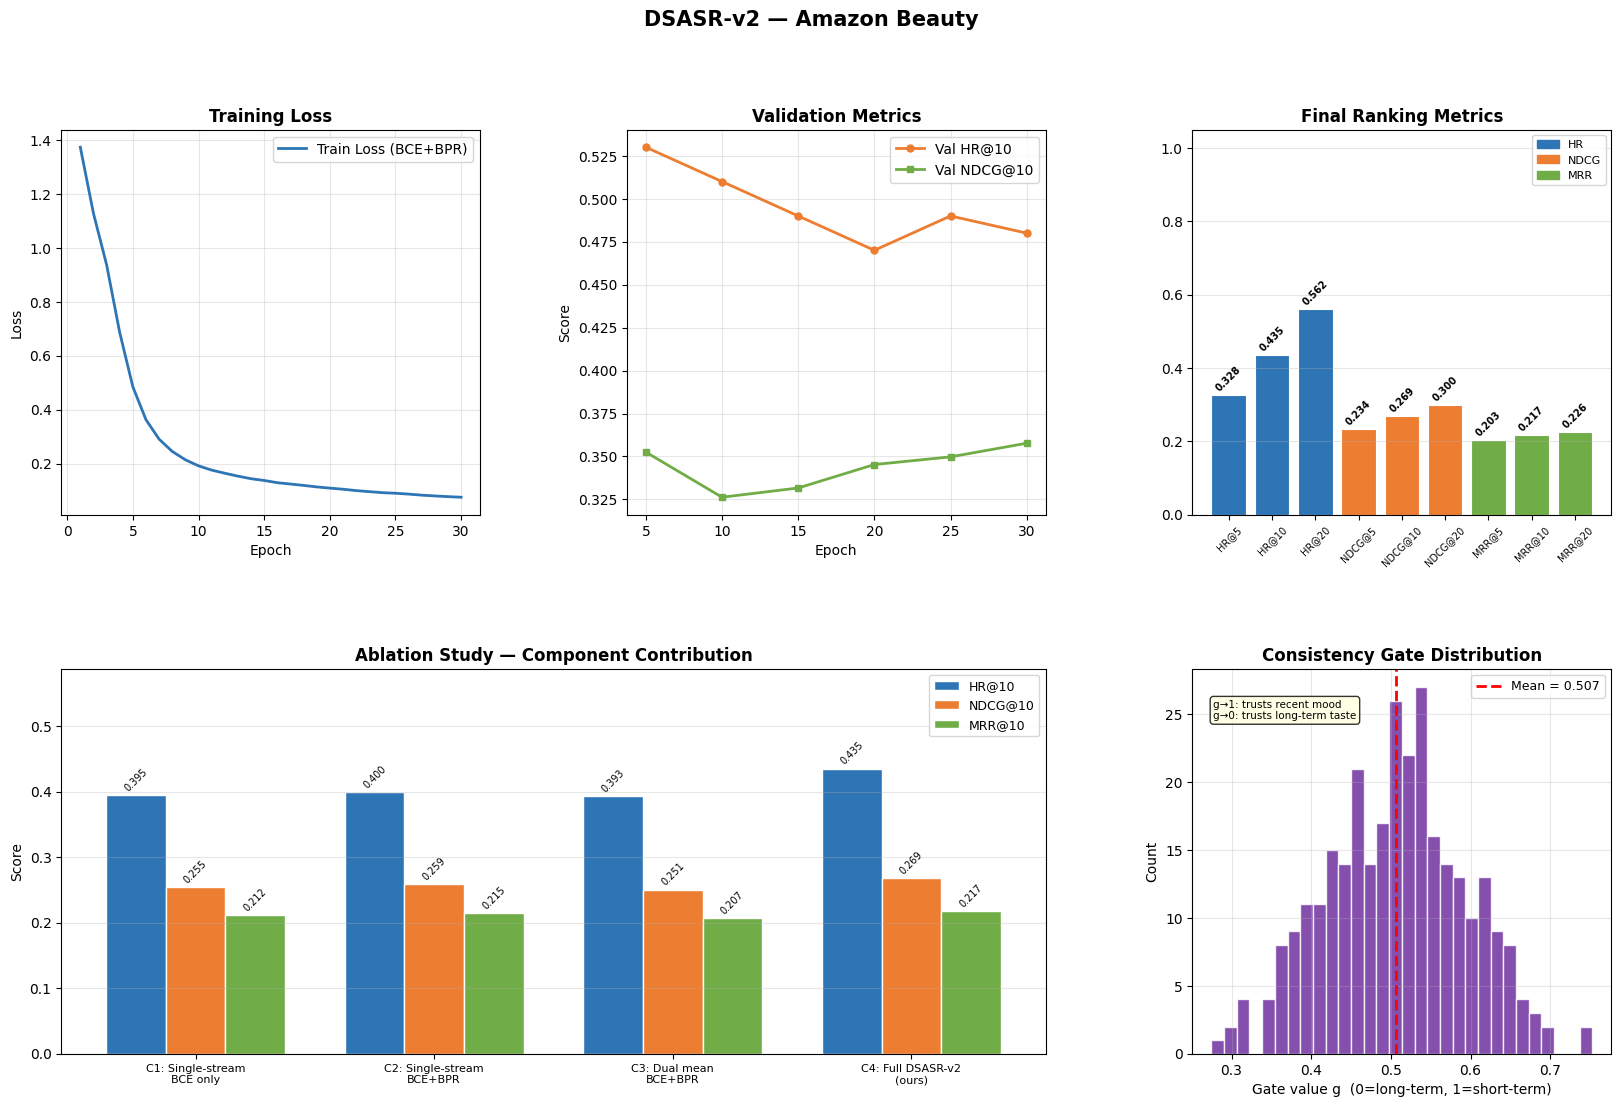

Plot saved: dsasr_v2_beauty_results.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# PLOTS: Training Loss | Val HR@10 | Results bar | Gate distribution
# ════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'DSASR-v2 — {DATASET_NAME}', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Training Loss curve ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(train_losses)+1), train_losses,
         color='#2E75B6', lw=2, label='Train Loss (BCE+BPR)')
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3); ax1.legend()

# ── 2. Val HR@10 & NDCG@10 over eval checkpoints ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
eval_epochs = list(range(EVAL_EVERY, len(train_losses)+1, EVAL_EVERY))[:len(val_hr10_hist)]
if len(eval_epochs) > 0 and len(val_hr10_hist) > 0:
    valid_len = min(len(eval_epochs), len(val_hr10_hist), len(val_nd10_hist))
    ax2.plot(eval_epochs[:valid_len], val_hr10_hist[:valid_len],
             color='#ED7D31', lw=2, marker='o', ms=5, label='Val HR@10')
    ax2.plot(eval_epochs[:valid_len], val_nd10_hist[:valid_len],
             color='#70AD47', lw=2, marker='s', ms=5, label='Val NDCG@10')
    ax2.set_title('Validation Metrics', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
    ax2.grid(True, alpha=0.3); ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Validation data\nnot available',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Validation Metrics', fontweight='bold')

# ── 3. Final ranking metrics bar chart ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metrics = ['HR@5','HR@10','HR@20','NDCG@5','NDCG@10','NDCG@20','MRR@5','MRR@10','MRR@20']
values  = ([hr_mean[n] for n in (5,10,20)] +
           [ndcg_mean[n] for n in (5,10,20)] +
           [mrr_mean[n] for n in (5,10,20)])
colors  = (['#2E75B6']*3 + ['#ED7D31']*3 + ['#70AD47']*3)
bars    = ax3.bar(metrics, values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)
ax3.set_ylim(0, 1.05)
ax3.set_title('Final Ranking Metrics', fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=7)
ax3.grid(axis='y', alpha=0.3)
# Add legend patches
from matplotlib.patches import Patch
ax3.legend(handles=[Patch(color='#2E75B6',label='HR'),
                    Patch(color='#ED7D31',label='NDCG'),
                    Patch(color='#70AD47',label='MRR')], fontsize=8)

# ── 4. Ablation bar chart ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
abl_labels = ['C1: Single-stream\nBCE only',
              'C2: Single-stream\nBCE+BPR',
              'C3: Dual mean\nBCE+BPR',
              'C4: Full DSASR-v2\n(ours)']
abl_hr   = [ablation_results[k][0] for k in ['C1','C2','C3','C4']]
abl_ndcg = [ablation_results[k][1] for k in ['C1','C2','C3','C4']]
abl_mrr  = [ablation_results[k][2] for k in ['C1','C2','C3','C4']]

x = np.arange(len(abl_labels))
w = 0.25
b1 = ax4.bar(x-w,   abl_hr,   w, label='HR@10',   color='#2E75B6', edgecolor='white')
b2 = ax4.bar(x,     abl_ndcg, w, label='NDCG@10', color='#ED7D31', edgecolor='white')
b3 = ax4.bar(x+w,   abl_mrr,  w, label='MRR@10',  color='#70AD47', edgecolor='white')
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        ax4.text(bar.get_x()+bar.get_width()/2., h+0.003,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
ax4.set_xticks(x); ax4.set_xticklabels(abl_labels, fontsize=8)
ax4.set_title('Ablation Study — Component Contribution', fontweight='bold')
ax4.set_ylabel('Score'); ax4.set_ylim(0, min(1.0, max(abl_hr)*1.35))
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

# ── 5. Gate value distribution ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
gate_vals = []
model.eval()
with torch.no_grad():
    sample = test_data[:min(300, len(test_data))]
    for uid, context, pos_item in sample:
        long_seq  = pad_or_trim(context, LONG_LEN)
        short_seq = long_seq[-SHORT_LEN:]
        age, gender, occ = user_meta[uid]
        batch = {
            'user_idx'  : torch.tensor([uid],      dtype=torch.long,    device=DEVICE),
            'age_norm'  : torch.tensor([[age]],     dtype=torch.float32, device=DEVICE),
            'gender_enc': torch.tensor([gender],    dtype=torch.long,    device=DEVICE),
            'occ_enc'   : torch.tensor([occ],       dtype=torch.long,    device=DEVICE),
            'long_seq'  : torch.tensor([long_seq],  dtype=torch.long,    device=DEVICE),
            'short_seq' : torch.tensor([short_seq], dtype=torch.long,    device=DEVICE),
            'pos_item'  : torch.tensor([pos_item],  dtype=torch.long,    device=DEVICE),
            'neg_items' : torch.zeros(1, N_NEG_TRAIN, dtype=torch.long,  device=DEVICE),
        }
        _, g = model.get_sequence_repr(batch)
        gate_vals.append(g.item())

ax5.hist(gate_vals, bins=30, color='#7030A0', edgecolor='white', alpha=0.85)
ax5.axvline(np.mean(gate_vals), color='red', lw=2, linestyle='--',
            label=f'Mean = {np.mean(gate_vals):.3f}')
ax5.set_title('Consistency Gate Distribution', fontweight='bold')
ax5.set_xlabel('Gate value g  (0=long-term, 1=short-term)')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)
ax5.text(0.05, 0.92, 'g→1: trusts recent mood\ng→0: trusts long-term taste',
         transform=ax5.transAxes, fontsize=7.5, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.savefig(f'dsasr_v2_{DATASET_TAG}_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: dsasr_v2_{DATASET_TAG}_results.png')